In [1]:
!pip install unrar
!unrar x /content/flight-delays.rar

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/

UNRAR 5.50 freeware      Copyright (c) 1993-2017 Alexander Roshal


Extracting from /content/flight-delays.rar

Creating    plots                                                     OK
Extracting  plots/airline.png                                              0%  OK 
Extracting  plots/ARR_DELAY Mean.png                                       1%  OK 
Extracting  plots/ARR_DELAY_NEW per airline .png                           2%  OK 
Extracting  plots/count flight .png                                        4%  OK 
Extracting  plots/dealy airline.png                                        5%  OK 
Extracting  plots/delay DEST STATE.png                                     9%  OK 
Extracting  plots/DELAY ORIGIN STATE.png                                  13%  OK 
Extracting  plots/DELAY state.png                                      

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

import time
import datetime, scipy 
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, BaggingRegressor

from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
data = pd.read_csv("T_ONTIME_REPORTING.csv")

In [4]:
air = pd.read_csv('airlines.csv')
air

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways
5,OO,Skywest Airlines Inc.
6,AS,Alaska Airlines Inc.
7,NK,Spirit Air Lines
8,WN,Southwest Airlines Co.
9,DL,Delta Air Lines Inc.


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537902 entries, 0 to 537901
Data columns (total 37 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 537902 non-null  int64  
 1   QUARTER              537902 non-null  int64  
 2   MONTH                537902 non-null  int64  
 3   DAY_OF_MONTH         537902 non-null  int64  
 4   DAY_OF_WEEK          537902 non-null  int64  
 5   FL_DATE              537902 non-null  object 
 6   OP_UNIQUE_CARRIER    537902 non-null  object 
 7   OP_CARRIER           537902 non-null  object 
 8   ORIGIN_AIRPORT_ID    537902 non-null  int64  
 9   ORIGIN_CITY_NAME     537902 non-null  object 
 10  ORIGIN_STATE_NM      537902 non-null  object 
 11  DEST_AIRPORT_ID      537902 non-null  int64  
 12  DEST_CITY_NAME       537902 non-null  object 
 13  DEST_STATE_NM        537902 non-null  object 
 14  CRS_DEP_TIME         537902 non-null  int64  
 15  DEP_TIME         

In [6]:
data.shape

(537902, 37)

In [7]:
data.describe()

,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,ORIGIN_AIRPORT_ID,DEST_AIRPORT_ID,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,...,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
count,537902.0,537902.0,537902.0,537902.000000,537902.000000,537902.000000,537902.000000,537902.000000,504999.000000,504988.000000,...,537902.000000,537902.000000,503529.000000,503529.000000,537902.000000,97052.000000,97052.000000,97052.000000,97052.000000,97052.000000
mean,2022.0,1.0,1.0,15.973075,4.043210,12654.034047,12654.072801,1325.209302,1332.776328,10.932093,...,0.002077,146.502006,139.961581,114.653845,820.829843,31.296037,4.097556,10.104789,0.126716,22.855500
std,0.0,0.0,0.0,8.981260,2.086759,1520.651360,1520.652221,484.061932,494.549178,50.084461,...,0.045522,72.698478,72.481665,70.669756,591.406577,75.982950,31.671466,24.073842,3.514664,52.226211
min,2022.0,1.0,1.0,1.000000,1.000000,10135.000000,10135.000000,1.000000,1.000000,-52.000000,...,0.000000,-48.000000,16.000000,8.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2022.0,1.0,1.0,8.000000,2.000000,11292.000000,11292.000000,915.000000,924.000000,-6.000000,...,0.000000,93.000000,86.000000,62.000000,390.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2022.0,1.0,1.0,16.000000,4.000000,12889.000000,12889.000000,1316.000000,1326.000000,-2.000000,...,0.000000,130.000000,125.000000,98.000000,679.000000,11.000000,0.000000,0.000000,0.000000,0.000000
75%,2022.0,1.0,1.0,24.000000,6.000000,14027.000000,14027.000000,1729.000000,1736.000000,8.000000,...,0.000000,178.000000,172.000000,145.000000,1065.000000,33.000000,0.000000,15.000000,0.000000,26.000000
max,2022.0,1.0,1.0,31.000000,7.000000,16869.000000,16869.000000,2359.000000,2400.000000,2512.000000,...,1.000000,685.000000,764.000000,727.000000,5095.000000,2512.000000,1665.000000,1294.000000,625.000000,2098.000000


In [8]:
data.head()

,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER,ORIGIN_AIRPORT_ID,ORIGIN_CITY_NAME,...,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,2022,1,1,14,5,1/14/2022 12:00:00 AM,YX,YX,11066,"Columbus, OH",...,0.0,88.0,95.0,63.0,323.0,NaN,NaN,NaN,NaN,NaN
1,2022,1,1,15,6,1/15/2022 12:00:00 AM,YX,YX,11066,"Columbus, OH",...,0.0,88.0,74.0,50.0,323.0,NaN,NaN,NaN,NaN,NaN
2,2022,1,1,16,7,1/16/2022 12:00:00 AM,YX,YX,11066,"Columbus, OH",...,0.0,88.0,81.0,53.0,323.0,NaN,NaN,NaN,NaN,NaN
3,2022,1,1,17,1,1/17/2022 12:00:00 AM,YX,YX,11066,"Columbus, OH",...,0.0,88.0,104.0,56.0,323.0,NaN,NaN,NaN,NaN,NaN
4,2022,1,1,18,2,1/18/2022 12:00:00 AM,YX,YX,11066,"Columbus, OH",...,0.0,88.0,65.0,48.0,323.0,NaN,NaN,NaN,NaN,NaN


In [9]:
data.tail()

,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER,ORIGIN_AIRPORT_ID,ORIGIN_CITY_NAME,...,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
537897,2022,1,1,6,4,1/6/2022 12:00:00 AM,DL,DL,11042,"Cleveland, OH",...,0.0,111.0,109.0,94.0,554.0,0.0,0.0,0.0,0.0,16.0
537898,2022,1,1,6,4,1/6/2022 12:00:00 AM,DL,DL,11433,"Detroit, MI",...,0.0,180.0,191.0,169.0,1145.0,0.0,124.0,11.0,0.0,0.0
537899,2022,1,1,6,4,1/6/2022 12:00:00 AM,DL,DL,10821,"Baltimore, MD",...,0.0,121.0,126.0,102.0,577.0,14.0,0.0,5.0,0.0,0.0
537900,2022,1,1,6,4,1/6/2022 12:00:00 AM,DL,DL,11057,"Charlotte, NC",...,0.0,75.0,65.0,46.0,226.0,NaN,NaN,NaN,NaN,NaN
537901,2022,1,1,6,4,1/6/2022 12:00:00 AM,DL,DL,14869,"Salt Lake City, UT",...,0.0,133.0,117.0,102.0,630.0,NaN,NaN,NaN,NaN,NaN


In [10]:
Data_NULL = data.isnull().sum() * 100/data.shape[0]
Data_NULL

YEAR                    0.000000
QUARTER                 0.000000
MONTH                   0.000000
DAY_OF_MONTH            0.000000
DAY_OF_WEEK             0.000000
FL_DATE                 0.000000
OP_UNIQUE_CARRIER       0.000000
OP_CARRIER              0.000000
ORIGIN_AIRPORT_ID       0.000000
ORIGIN_CITY_NAME        0.000000
ORIGIN_STATE_NM         0.000000
DEST_AIRPORT_ID         0.000000
DEST_CITY_NAME          0.000000
DEST_STATE_NM           0.000000
CRS_DEP_TIME            0.000000
DEP_TIME                6.116913
DEP_DELAY               6.118958
DEP_DELAY_NEW           6.118958
TAXI_OUT                6.159672
WHEELS_OFF              6.159672
WHEELS_ON               6.222137
TAXI_IN                 6.222137
CRS_ARR_TIME            0.000000
ARR_TIME                6.221765
ARR_DELAY               6.390197
ARR_DELAY_NEW           6.390197
CANCELLED               0.000000
DIVERTED                0.000000
CRS_ELAPSED_TIME        0.000000
ACTUAL_ELAPSED_TIME     6.390197
AIR_TIME  

In [11]:
thre = .75

def drop_null_col(dataframe):
    temp = pd.DataFrame(dataframe.isnull().sum())
    temp.columns = ['num']
    temp['name'] = temp.index
    temp.reset_index(drop=True, inplace=True)
    temp['num'] = (temp['num'] / len(dataframe))
            
    for index, row in temp.iterrows():
        if(row['num']>=thre):
            dataframe.drop([row['name']], axis=1, inplace=True)
    
    return dataframe

In [12]:
data = drop_null_col(data)

In [13]:
data.isnull().sum() * 100/data.shape[0]

YEAR                   0.000000
QUARTER                0.000000
MONTH                  0.000000
DAY_OF_MONTH           0.000000
DAY_OF_WEEK            0.000000
FL_DATE                0.000000
OP_UNIQUE_CARRIER      0.000000
OP_CARRIER             0.000000
ORIGIN_AIRPORT_ID      0.000000
ORIGIN_CITY_NAME       0.000000
ORIGIN_STATE_NM        0.000000
DEST_AIRPORT_ID        0.000000
DEST_CITY_NAME         0.000000
DEST_STATE_NM          0.000000
CRS_DEP_TIME           0.000000
DEP_TIME               6.116913
DEP_DELAY              6.118958
DEP_DELAY_NEW          6.118958
TAXI_OUT               6.159672
WHEELS_OFF             6.159672
WHEELS_ON              6.222137
TAXI_IN                6.222137
CRS_ARR_TIME           0.000000
ARR_TIME               6.221765
ARR_DELAY              6.390197
ARR_DELAY_NEW          6.390197
CANCELLED              0.000000
DIVERTED               0.000000
CRS_ELAPSED_TIME       0.000000
ACTUAL_ELAPSED_TIME    6.390197
AIR_TIME               6.390197
DISTANCE

In [14]:
data.dtypes

YEAR                     int64
QUARTER                  int64
MONTH                    int64
DAY_OF_MONTH             int64
DAY_OF_WEEK              int64
FL_DATE                 object
OP_UNIQUE_CARRIER       object
OP_CARRIER              object
ORIGIN_AIRPORT_ID        int64
ORIGIN_CITY_NAME        object
ORIGIN_STATE_NM         object
DEST_AIRPORT_ID          int64
DEST_CITY_NAME          object
DEST_STATE_NM           object
CRS_DEP_TIME             int64
DEP_TIME               float64
DEP_DELAY              float64
DEP_DELAY_NEW          float64
TAXI_OUT               float64
WHEELS_OFF             float64
WHEELS_ON              float64
TAXI_IN                float64
CRS_ARR_TIME             int64
ARR_TIME               float64
ARR_DELAY              float64
ARR_DELAY_NEW          float64
CANCELLED              float64
DIVERTED               float64
CRS_ELAPSED_TIME       float64
ACTUAL_ELAPSED_TIME    float64
AIR_TIME               float64
DISTANCE               float64
dtype: o

In [15]:
def format_heure(chaine):
    if pd.isnull(chaine):
        return np.nan
    else:
        if chaine == 2400: chaine = 0
        chaine = "{0:04d}".format(int(chaine))
        heure = datetime.time(int(chaine[0:2]), int(chaine[2:4]))
        return heure

In [16]:
data['Actual_Departure'] = data['DEP_TIME'].apply(format_heure)
data['Actual_WHEELS_OFF'] = data['WHEELS_OFF'].apply(format_heure)
data['Actual_WHEELS_ON'] = data['WHEELS_ON'].apply(format_heure)
data['Actual_Arrival'] = data['ARR_TIME'].apply(format_heure)

In [17]:
data.head()

,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER,ORIGIN_AIRPORT_ID,ORIGIN_CITY_NAME,...,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,Actual_Departure,Actual_WHEELS_OFF,Actual_WHEELS_ON,Actual_Arrival
0,2022,1,1,14,5,1/14/2022 12:00:00 AM,YX,YX,11066,"Columbus, OH",...,0.0,0.0,88.0,95.0,63.0,323.0,12:21:00,12:49:00,13:52:00,13:56:00
1,2022,1,1,15,6,1/15/2022 12:00:00 AM,YX,YX,11066,"Columbus, OH",...,0.0,0.0,88.0,74.0,50.0,323.0,12:14:00,12:33:00,13:23:00,13:28:00
2,2022,1,1,16,7,1/16/2022 12:00:00 AM,YX,YX,11066,"Columbus, OH",...,0.0,0.0,88.0,81.0,53.0,323.0,12:18:00,12:34:00,13:27:00,13:39:00
3,2022,1,1,17,1,1/17/2022 12:00:00 AM,YX,YX,11066,"Columbus, OH",...,0.0,0.0,88.0,104.0,56.0,323.0,12:17:00,12:49:00,13:45:00,14:01:00
4,2022,1,1,18,2,1/18/2022 12:00:00 AM,YX,YX,11066,"Columbus, OH",...,0.0,0.0,88.0,65.0,48.0,323.0,12:18:00,12:29:00,13:17:00,13:23:00


In [18]:
data.columns

Index(['YEAR', 'QUARTER', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE',
       'OP_UNIQUE_CARRIER', 'OP_CARRIER', 'ORIGIN_AIRPORT_ID',
       'ORIGIN_CITY_NAME', 'ORIGIN_STATE_NM', 'DEST_AIRPORT_ID',
       'DEST_CITY_NAME', 'DEST_STATE_NM', 'CRS_DEP_TIME', 'DEP_TIME',
       'DEP_DELAY', 'DEP_DELAY_NEW', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON',
       'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'ARR_DELAY_NEW',
       'CANCELLED', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME',
       'AIR_TIME', 'DISTANCE', 'Actual_Departure', 'Actual_WHEELS_OFF',
       'Actual_WHEELS_ON', 'Actual_Arrival'],
      dtype='object')

In [19]:
air_dic = {}
for index, row in air.iterrows():
    air_dic[row['IATA_CODE']] = row['AIRLINE']

In [20]:
air_dic

{'9E': 'Endeavor Air',
 'AA': 'American Airlines Inc.',
 'AS': 'Alaska Airlines Inc.',
 'B6': 'JetBlue Airways',
 'DL': 'Delta Air Lines Inc.',
 'EV': 'Atlantic Southeast Airlines',
 'F9': 'Frontier Airlines Inc.',
 'G4': 'Allegiant Air',
 'HA': 'Hawaiian Airlines Inc.',
 'MQ': 'American Eagle Airlines Inc.',
 'NK': 'Spirit Air Lines',
 'OH': 'PSA Airlines',
 'OO': 'Skywest Airlines Inc.',
 'QX': 'Horizon Air',
 'UA': 'United Air Lines Inc.',
 'US': 'US Airways Inc.',
 'VX': 'Virgin America',
 'WN': 'Southwest Airlines Co.',
 'YV': 'Mesa Airlines',
 'YX': 'MIDEX'}

In [21]:
data['airline'] = data['OP_CARRIER']
data.replace({"airline": air_dic}, inplace=True)

In [22]:
data['airline'].value_counts()

Southwest Airlines Co.          97436
American Airlines Inc.          69400
Delta Air Lines Inc.            68963
Skywest Airlines Inc.           63146
United Air Lines Inc.           45741
MIDEX                           27261
American Eagle Airlines Inc.    22205
Endeavor Air                    21644
JetBlue Airways                 21332
PSA Airlines                    20541
Spirit Air Lines                17554
Alaska Airlines Inc.            16549
Frontier Airlines Inc.          12039
Mesa Airlines                   11404
Allegiant Air                    8714
Horizon Air                      8105
Hawaiian Airlines Inc.           5868
Name: airline, dtype: int64

In [23]:
def get_stats(group):
    return {'min': group.min(), 'max': group.max(),
            'count': group.count(), 'mean': group.mean()}

In [24]:
def show_get_stats(dataframe, feature):
    return dataframe[feature].groupby(dataframe['airline']).apply(get_stats).unstack().sort_values('count')

In [25]:
data['ARR_DELAY'].mean()

3.9810854985512254

In [26]:
show_get_stats(data, 'ARR_DELAY')

,min,max,count,mean
airline,,,,
Hawaiian Airlines Inc.,-63.0,930.0,5640.0,6.884220
Horizon Air,-40.0,540.0,7649.0,10.964571
Allegiant Air,-57.0,620.0,7975.0,12.243135
Mesa Airlines,-72.0,1241.0,9920.0,11.159476
Frontier Airlines Inc.,-64.0,1284.0,11486.0,10.955163
Alaska Airlines Inc.,-70.0,825.0,15204.0,5.233294
Spirit Air Lines,-47.0,1294.0,16933.0,8.520168
PSA Airlines,-65.0,1388.0,18262.0,10.698828
JetBlue Airways,-100.0,1654.0,19192.0,18.721082


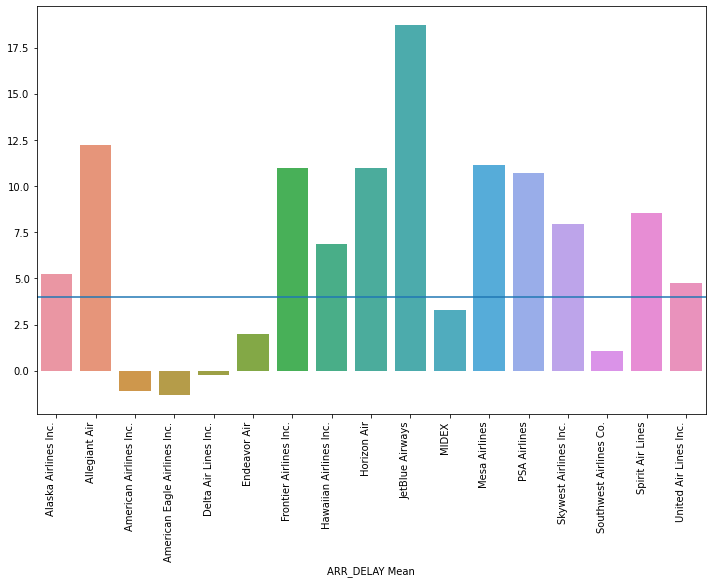

In [27]:
my_dict = data['ARR_DELAY'].groupby(data['airline']).mean().to_dict()
keys = list(my_dict.keys())
vals = list(my_dict.values())

plt.figure(figsize=(10, 8))
axis = sns.barplot(x=keys, y=vals)
axis.set_xticklabels(axis.get_xticklabels(), rotation=90, ha="right")
plt.tight_layout()
plt.xlabel('ARR_DELAY Mean')
axis.axhline(data['ARR_DELAY'].mean())
plt.savefig("plots/ARR_DELAY Mean.png", dpi=300)
plt.show()

In [28]:
show_get_stats(data, 'ARR_DELAY_NEW')

,min,max,count,mean
airline,,,,
Hawaiian Airlines Inc.,0.0,930.0,5640.0,12.912057
Horizon Air,0.0,540.0,7649.0,15.949274
Allegiant Air,0.0,620.0,7975.0,19.353856
Mesa Airlines,0.0,1241.0,9920.0,20.947581
Frontier Airlines Inc.,0.0,1284.0,11486.0,19.479105
Alaska Airlines Inc.,0.0,825.0,15204.0,13.670218
Spirit Air Lines,0.0,1294.0,16933.0,16.025749
PSA Airlines,0.0,1388.0,18262.0,20.042109
JetBlue Airways,0.0,1654.0,19192.0,27.769435


In [29]:
show_get_stats(data, 'DEP_DELAY')

,min,max,count,mean
airline,,,,
Hawaiian Airlines Inc.,-32.0,909.0,5651.0,9.558308
Horizon Air,-36.0,530.0,7706.0,12.158578
Allegiant Air,-37.0,619.0,7997.0,12.150682
Mesa Airlines,-23.0,1224.0,9959.0,18.966965
Frontier Airlines Inc.,-40.0,1267.0,11510.0,15.565161
Alaska Airlines Inc.,-52.0,826.0,15294.0,8.076828
Spirit Air Lines,-29.0,1302.0,16963.0,11.747568
PSA Airlines,-49.0,1351.0,18349.0,14.828111
JetBlue Airways,-32.0,1661.0,19269.0,23.401837


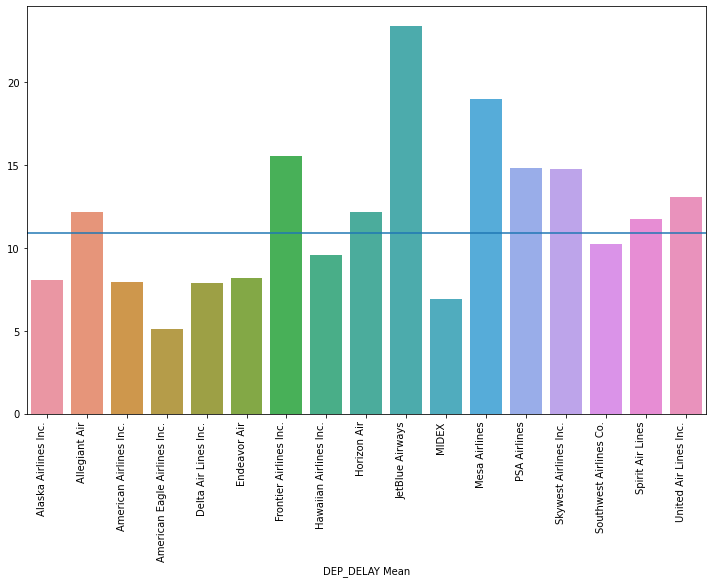

In [30]:
my_dict = data['DEP_DELAY'].groupby(data['airline']).mean().to_dict()
keys = list(my_dict.keys())
vals = list(my_dict.values())

plt.figure(figsize=(10, 8))
axis = sns.barplot(x=keys, y=vals)
axis.set_xticklabels(axis.get_xticklabels(), rotation=90, ha="right")
plt.tight_layout()
plt.xlabel('DEP_DELAY Mean')
axis.axhline(data['DEP_DELAY'].mean())
plt.savefig("plots/DEP_DELAY Mean.png", dpi=300)
plt.show()

In [31]:
show_get_stats(data, 'DEP_DELAY_NEW')

,min,max,count,mean
airline,,,,
Hawaiian Airlines Inc.,0.0,909.0,5651.0,12.482569
Horizon Air,0.0,530.0,7706.0,14.951856
Allegiant Air,0.0,619.0,7997.0,17.371139
Mesa Airlines,0.0,1224.0,9959.0,21.982127
Frontier Airlines Inc.,0.0,1267.0,11510.0,19.773675
Alaska Airlines Inc.,0.0,826.0,15294.0,12.750425
Spirit Air Lines,0.0,1302.0,16963.0,15.097035
PSA Airlines,0.0,1351.0,18349.0,19.478173
JetBlue Airways,0.0,1661.0,19269.0,27.547252


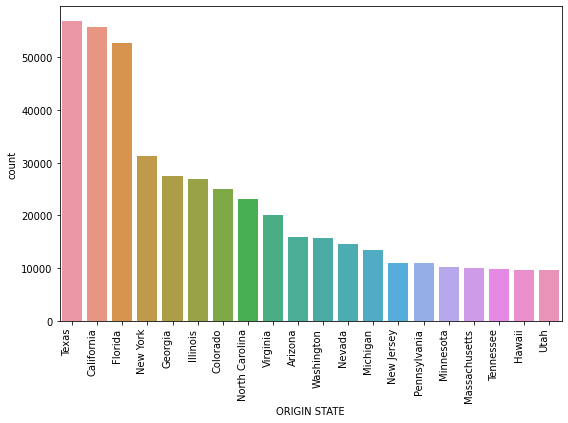

In [32]:
plt.figure(figsize=(8, 6))

axis = sns.countplot(x=data['ORIGIN_STATE_NM'],
                       data=data,
                       order=data['ORIGIN_STATE_NM'].value_counts().iloc[:20].index)
axis.set_xticklabels(axis.get_xticklabels(), rotation=90, ha="right")
plt.tight_layout()
plt.xlabel('ORIGIN STATE')
plt.savefig("plots/ORIGIN_STATE.png", dpi=300)
plt.show()

In [33]:
data['ORIGIN_STATE_NM'].value_counts()

Texas                                             56822
California                                        55750
Florida                                           52729
New York                                          31193
Georgia                                           27518
Illinois                                          26839
Colorado                                          25095
North Carolina                                    23028
Virginia                                          20163
Arizona                                           15853
Washington                                        15745
Nevada                                            14600
Michigan                                          13507
New Jersey                                        10973
Pennsylvania                                      10941
Minnesota                                         10241
Massachusetts                                     10062
Tennessee                                       

In [34]:
data['DEST_STATE_NM'].value_counts()

Texas                                             56824
California                                        55746
Florida                                           52710
New York                                          31198
Georgia                                           27504
Illinois                                          26875
Colorado                                          25091
North Carolina                                    23021
Virginia                                          20184
Arizona                                           15869
Washington                                        15742
Nevada                                            14597
Michigan                                          13490
New Jersey                                        10942
Pennsylvania                                      10942
Minnesota                                         10235
Massachusetts                                     10061
Tennessee                                       

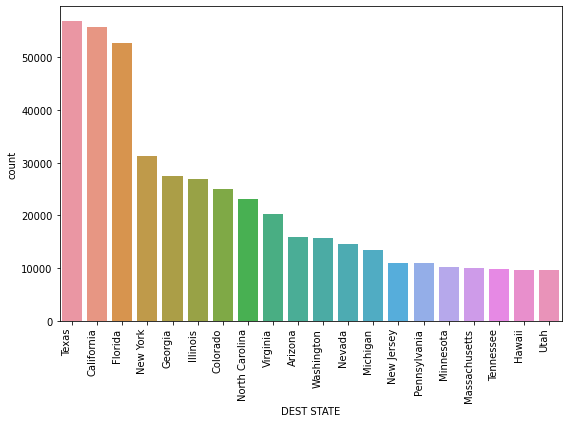

In [35]:
plt.figure(figsize=(8, 6))

axis = sns.countplot(x=data['DEST_STATE_NM'],
                       data=data,
                       order=data['DEST_STATE_NM'].value_counts().iloc[:20].index)
axis.set_xticklabels(axis.get_xticklabels(), rotation=90, ha="right")
plt.tight_layout()
plt.xlabel('DEST STATE')
plt.savefig("plots/DEST STATE.png", dpi=300)
plt.show()

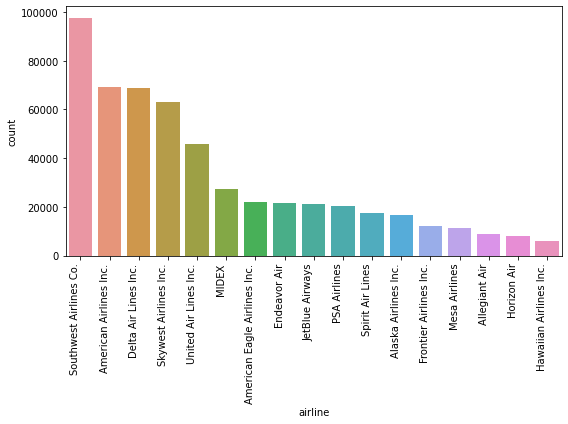

In [36]:
plt.figure(figsize=(8, 6))

axis = sns.countplot(x=data['airline'],
                       data=data,
                       order=data['airline'].value_counts().iloc[:].index)
axis.set_xticklabels(axis.get_xticklabels(), rotation=90, ha="right")
plt.tight_layout()
plt.xlabel('airline')
plt.savefig("plots/airline.png", dpi=300)
plt.show()

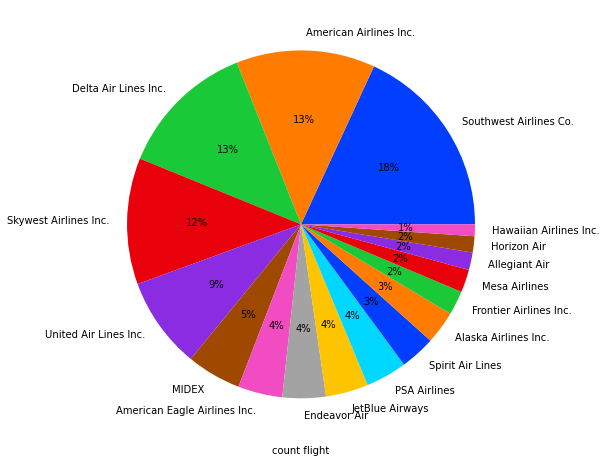

In [37]:
plt.figure(figsize=(8, 8))

data2 = data['airline'].value_counts().values
keys = data['airline'].value_counts().index
  
palette_color = sns.color_palette('bright')
plt.pie(data2, labels=keys, colors=palette_color, autopct='%.0f%%')
plt.xlabel('count flight')
plt.savefig("plots/count flight .png", dpi=300)
plt.show()

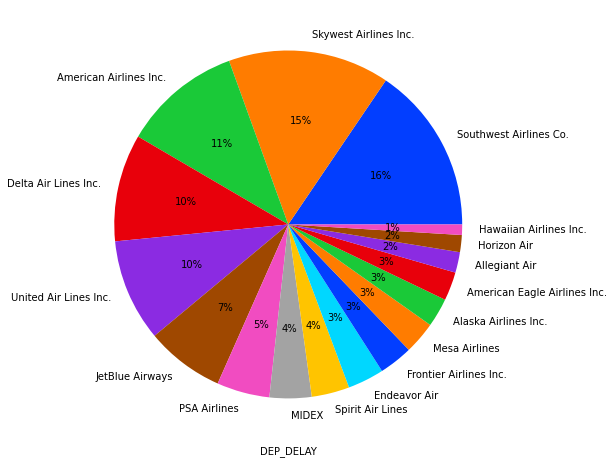

In [38]:
plt.figure(figsize=(8, 8))

data2 = data.groupby('airline')['DEP_DELAY_NEW'].sum().sort_values(ascending=False).values
keys = data.groupby('airline')['DEP_DELAY_NEW'].sum().sort_values(ascending=False).index
  
palette_color = sns.color_palette('bright')
plt.pie(data2, labels=keys, colors=palette_color, autopct='%.0f%%')
plt.xlabel('DEP_DELAY')
plt.savefig("plots/DEP_DELAY_NEW per airline .png", dpi=300)
plt.show()

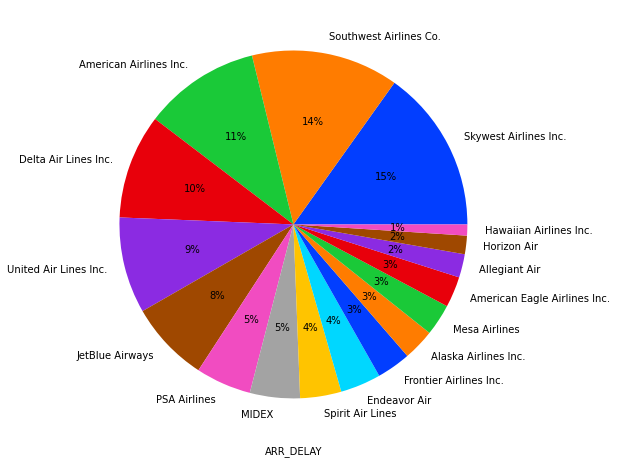

In [39]:
plt.figure(figsize=(8, 8))

data2 = data.groupby('airline')['ARR_DELAY_NEW'].sum().sort_values(ascending=False).values
keys = data.groupby('airline')['ARR_DELAY_NEW'].sum().sort_values(ascending=False).index
  
palette_color = sns.color_palette('bright')
plt.pie(data2, labels=keys, colors=palette_color, autopct='%.0f%%')
plt.xlabel('ARR_DELAY')
plt.savefig("plots/ARR_DELAY_NEW per airline .png", dpi=300)
plt.show()

In [40]:
temp_df = pd.DataFrame()
temp_df['airline'] = data['DISTANCE'].groupby(data['airline']).mean().to_dict().keys()
temp_df['arrival delay'] = data['ARR_DELAY'].groupby(data['airline']).mean().to_dict().values()
temp_df['distance'] = data['DISTANCE'].groupby(data['airline']).mean().to_dict().values()

fig = px.scatter(temp_df, x="distance", y="arrival delay", text="airline", size_max=100)
fig.update_traces(textposition='top center')
fig.update_layout(title_text='Distance vs Arrival Delay', title_x=0.5)
fig.show()

In [41]:
temp_df = pd.DataFrame()
temp_df['airline'] = data['DISTANCE'].groupby(data['airline']).mean().to_dict().keys()
temp_df['DEP delay'] = data['DEP_DELAY'].groupby(data['airline']).mean().to_dict().values()
temp_df['distance'] = data['DISTANCE'].groupby(data['airline']).mean().to_dict().values()

fig = px.scatter(temp_df, x="distance", y="DEP delay", text="airline", size_max=100)
fig.update_traces(textposition='top center')
fig.update_layout(title_text='Distance vs DEP Delay', title_x=0.5)
fig.show()

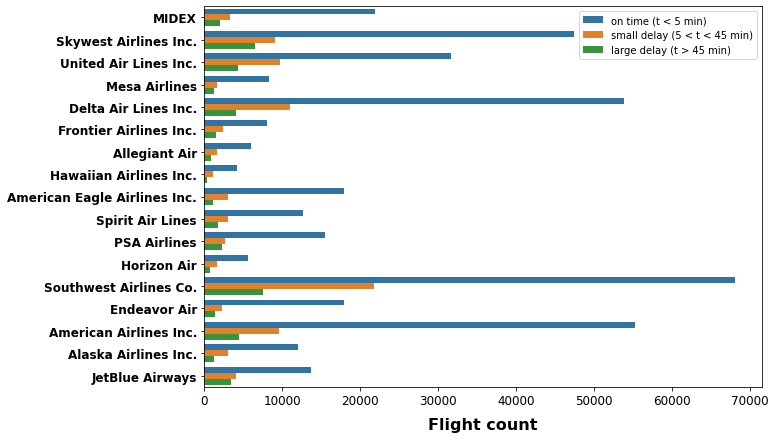

In [42]:
delay_type = lambda x:((0, 1)[x>5], 2)[x>45]
data['DELAY_LEVEL'] = data['DEP_DELAY'].apply(delay_type)

fig = plt.figure(1, figsize=(10, 7))
ax = sns.countplot(y="airline", hue='DELAY_LEVEL', data=data)

labels = [item.get_text() for item in ax.get_yticklabels()]
ax.set_yticklabels(labels)
plt.setp(ax.get_xticklabels(), fontsize=12, weight = 'normal', rotation = 0);
plt.setp(ax.get_yticklabels(), fontsize=12, weight = 'bold', rotation = 0);
ax.yaxis.label.set_visible(False)
plt.xlabel('Flight count', fontsize=16, weight = 'bold', labelpad=10)

L = plt.legend()
L.get_texts()[0].set_text('on time (t < 5 min)')
L.get_texts()[1].set_text('small delay (5 < t < 45 min)')
L.get_texts()[2].set_text('large delay (t > 45 min)')
plt.show()

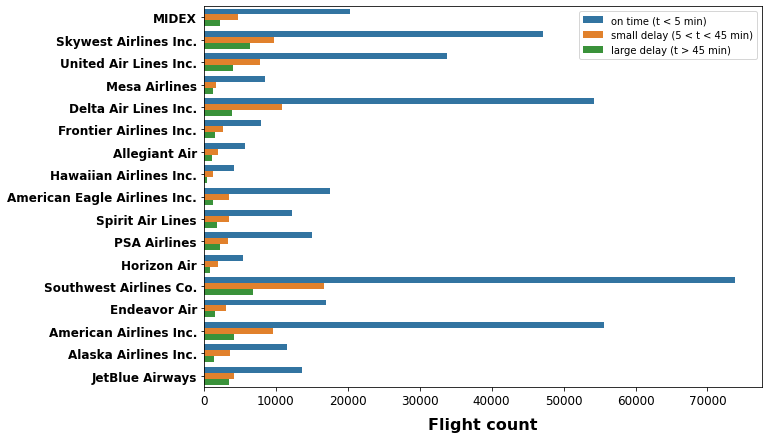

In [43]:
delay_type = lambda x:((0, 1)[x>5], 2)[x>45]
data['DELAY_LEVEL2'] = data['ARR_DELAY'].apply(delay_type)

fig = plt.figure(1, figsize=(10, 7))
ax = sns.countplot(y="airline", hue='DELAY_LEVEL2', data=data)

labels = [item.get_text() for item in ax.get_yticklabels()]
ax.set_yticklabels(labels)
plt.setp(ax.get_xticklabels(), fontsize=12, weight = 'normal', rotation = 0);
plt.setp(ax.get_yticklabels(), fontsize=12, weight = 'bold', rotation = 0);
ax.yaxis.label.set_visible(False)
plt.xlabel('Flight count', fontsize=16, weight = 'bold', labelpad=10)

L = plt.legend()
L.get_texts()[0].set_text('on time (t < 5 min)')
L.get_texts()[1].set_text('small delay (5 < t < 45 min)')
L.get_texts()[2].set_text('large delay (t > 45 min)')
plt.show()

In [44]:
cut_dealy = pd.DataFrame(pd.cut(data["ARR_DELAY"], 20))
cut_dealy["ARR_DELAY"].value_counts()

(-102.636, 31.8]    442808
(31.8, 163.6]        53600
(163.6, 295.4]        5228
(295.4, 427.2]         993
(427.2, 559.0]         275
(559.0, 690.8]         185
(690.8, 822.6]         137
(822.6, 954.4]         121
(954.4, 1086.2]         65
(1086.2, 1218.0]        57
(1218.0, 1349.8]        26
(1481.6, 1613.4]        12
(1349.8, 1481.6]         9
(1613.4, 1745.2]         7
(1745.2, 1877.0]         2
(2008.8, 2140.6]         2
(2404.2, 2536.0]         2
(1877.0, 2008.8]         0
(2140.6, 2272.4]         0
(2272.4, 2404.2]         0
Name: ARR_DELAY, dtype: int64

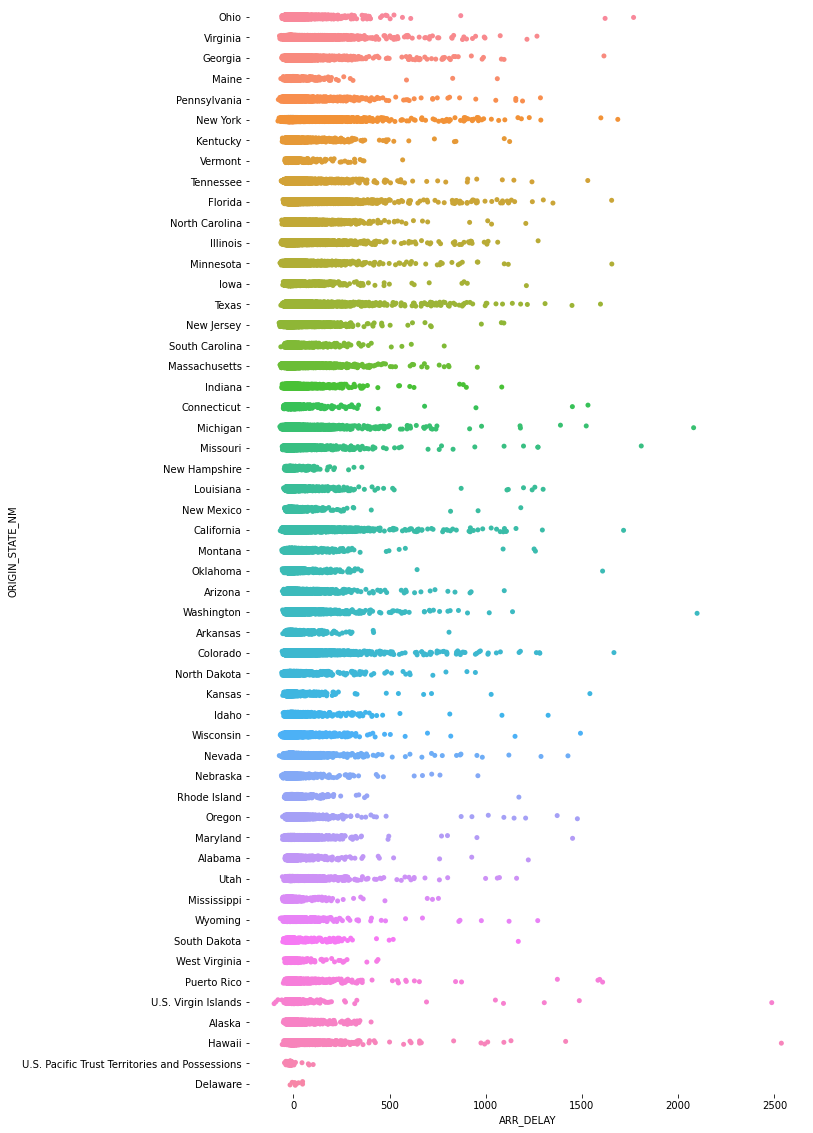

In [45]:
axis = plt.subplots(figsize=(10, 20))
sns.despine(bottom=True, left=True)

sns.stripplot(x="ARR_DELAY", 
              y="ORIGIN_STATE_NM",
              data=data, 
              dodge=True, 
              jitter=True
            )
plt.savefig("plots/DELAY ORIGIN STATE.png", dpi=300)
plt.show()

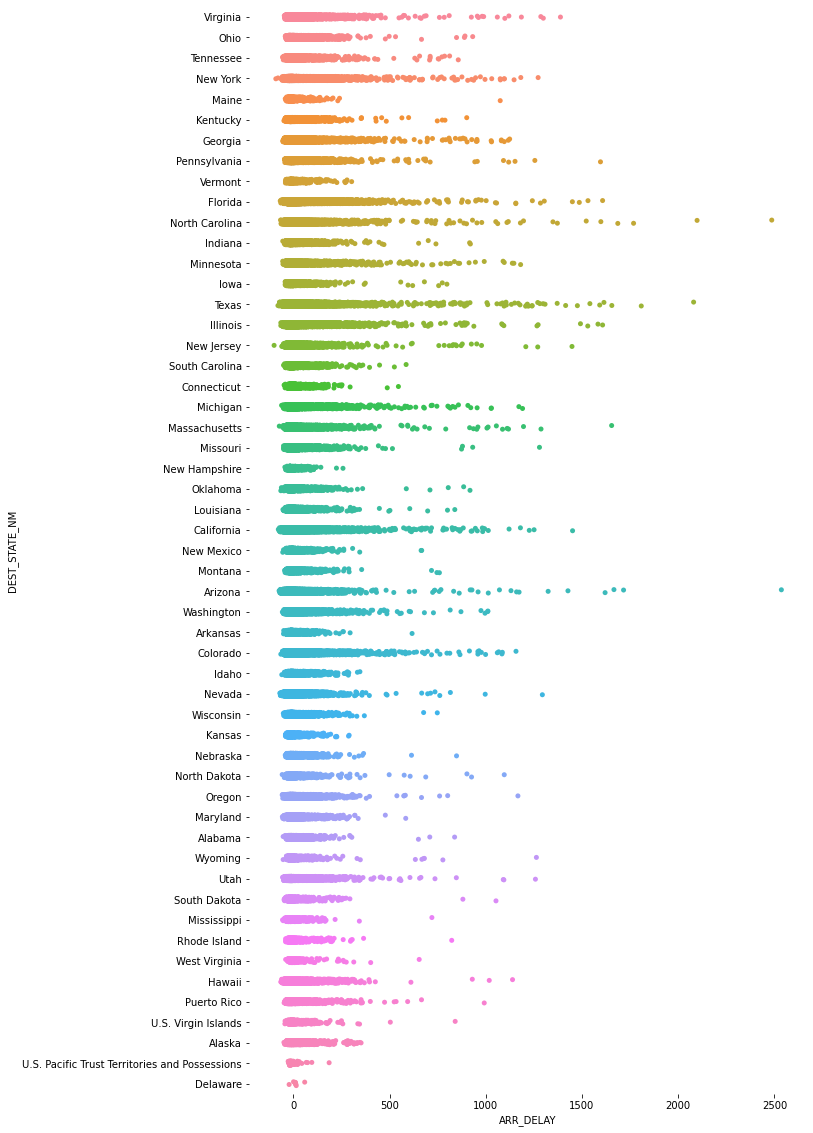

In [46]:
axis = plt.subplots(figsize=(10, 20))
sns.despine(bottom=True, left=True)

sns.stripplot(x="ARR_DELAY", 
              y="DEST_STATE_NM",
              data=data, 
              dodge=True, 
              jitter=True
            )
plt.savefig("plots/delay DEST STATE.png", dpi=300)
plt.show()

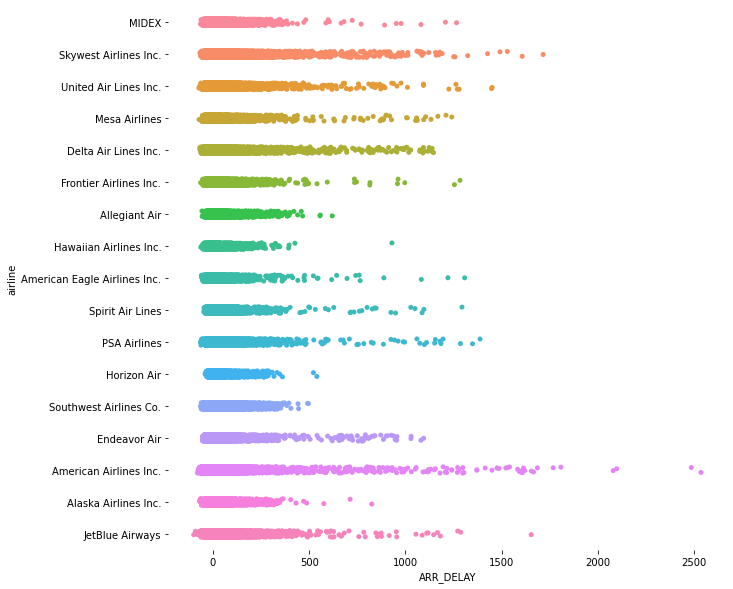

In [47]:
axis = plt.subplots(figsize=(10, 10))
sns.despine(bottom=True, left=True)

sns.stripplot(x="ARR_DELAY", 
              y="airline",
              data=data, 
              dodge=True, 
              jitter=True
            )
plt.savefig("plots/dealy airline.png", dpi=300)
plt.show()

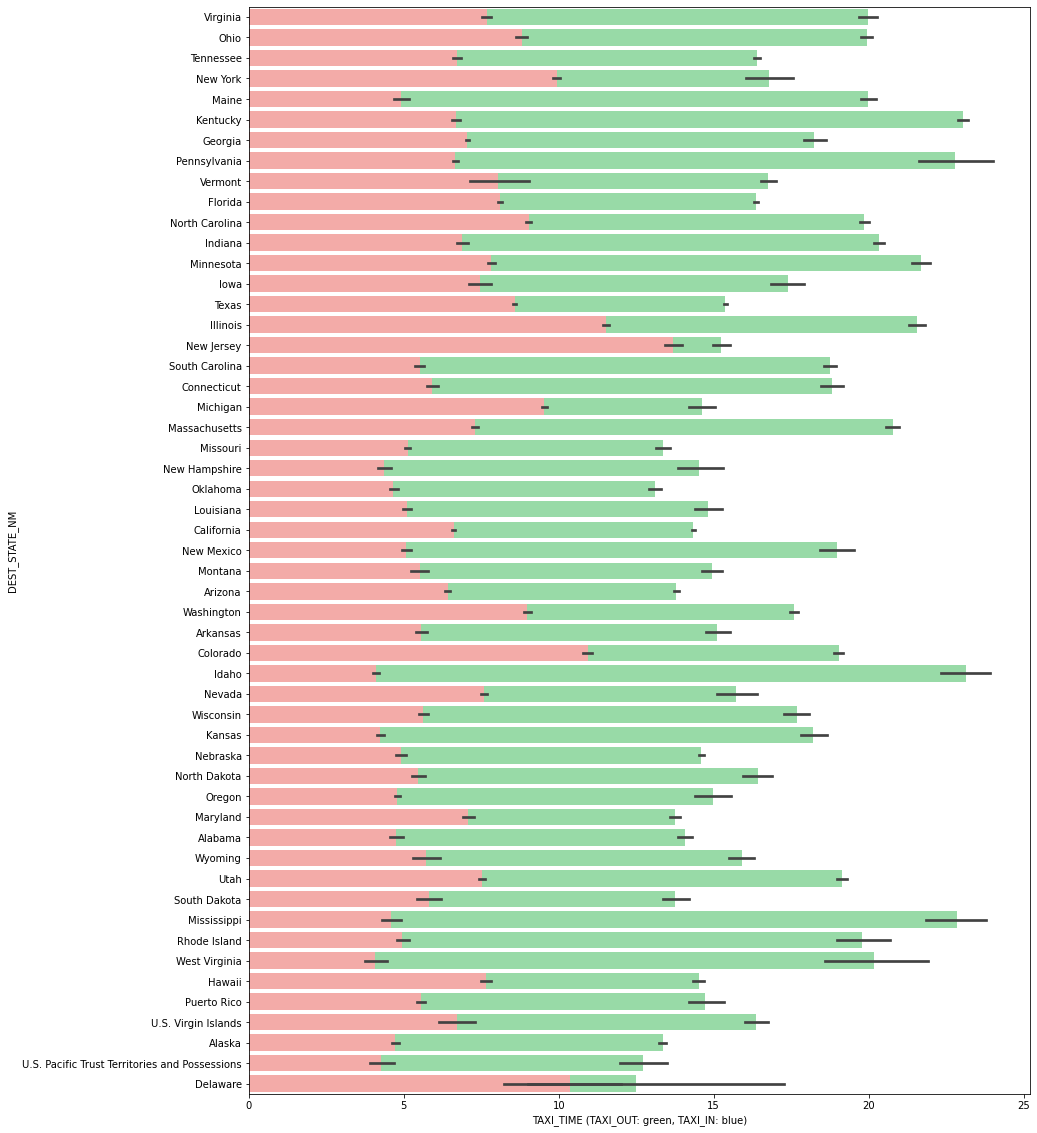

In [48]:
axis = plt.subplots(figsize=(14, 20))
sns.set_color_codes("pastel")
sns.set_context("notebook", font_scale=1.5)
axis = sns.barplot(x="TAXI_OUT", y="ORIGIN_STATE_NM", data=data, color="g")
axis = sns.barplot(x="TAXI_IN", y="DEST_STATE_NM", data=data, color="r")
axis.set(xlabel="TAXI_TIME (TAXI_OUT: green, TAXI_IN: blue)")
plt.savefig("plots/TAXI IN OUT.png", dpi=300)

In [49]:
data.columns

Index(['YEAR', 'QUARTER', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE',
       'OP_UNIQUE_CARRIER', 'OP_CARRIER', 'ORIGIN_AIRPORT_ID',
       'ORIGIN_CITY_NAME', 'ORIGIN_STATE_NM', 'DEST_AIRPORT_ID',
       'DEST_CITY_NAME', 'DEST_STATE_NM', 'CRS_DEP_TIME', 'DEP_TIME',
       'DEP_DELAY', 'DEP_DELAY_NEW', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON',
       'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'ARR_DELAY_NEW',
       'CANCELLED', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME',
       'AIR_TIME', 'DISTANCE', 'Actual_Departure', 'Actual_WHEELS_OFF',
       'Actual_WHEELS_ON', 'Actual_Arrival', 'airline', 'DELAY_LEVEL',
       'DELAY_LEVEL2'],
      dtype='object')

In [50]:
# Constants
#year month day flights
c = [  'DAY_OF_MONTH', 'DAY_OF_WEEK',
       'CRS_DEP_TIME', 'DEP_TIME',
       'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON',
       'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME',
       'AIR_TIME', 'DISTANCE', 'Actual_Departure', 'Actual_WHEELS_OFF',
       'Actual_WHEELS_ON', 'Actual_Arrival', 'DELAY_LEVEL',
       'DELAY_LEVEL2']

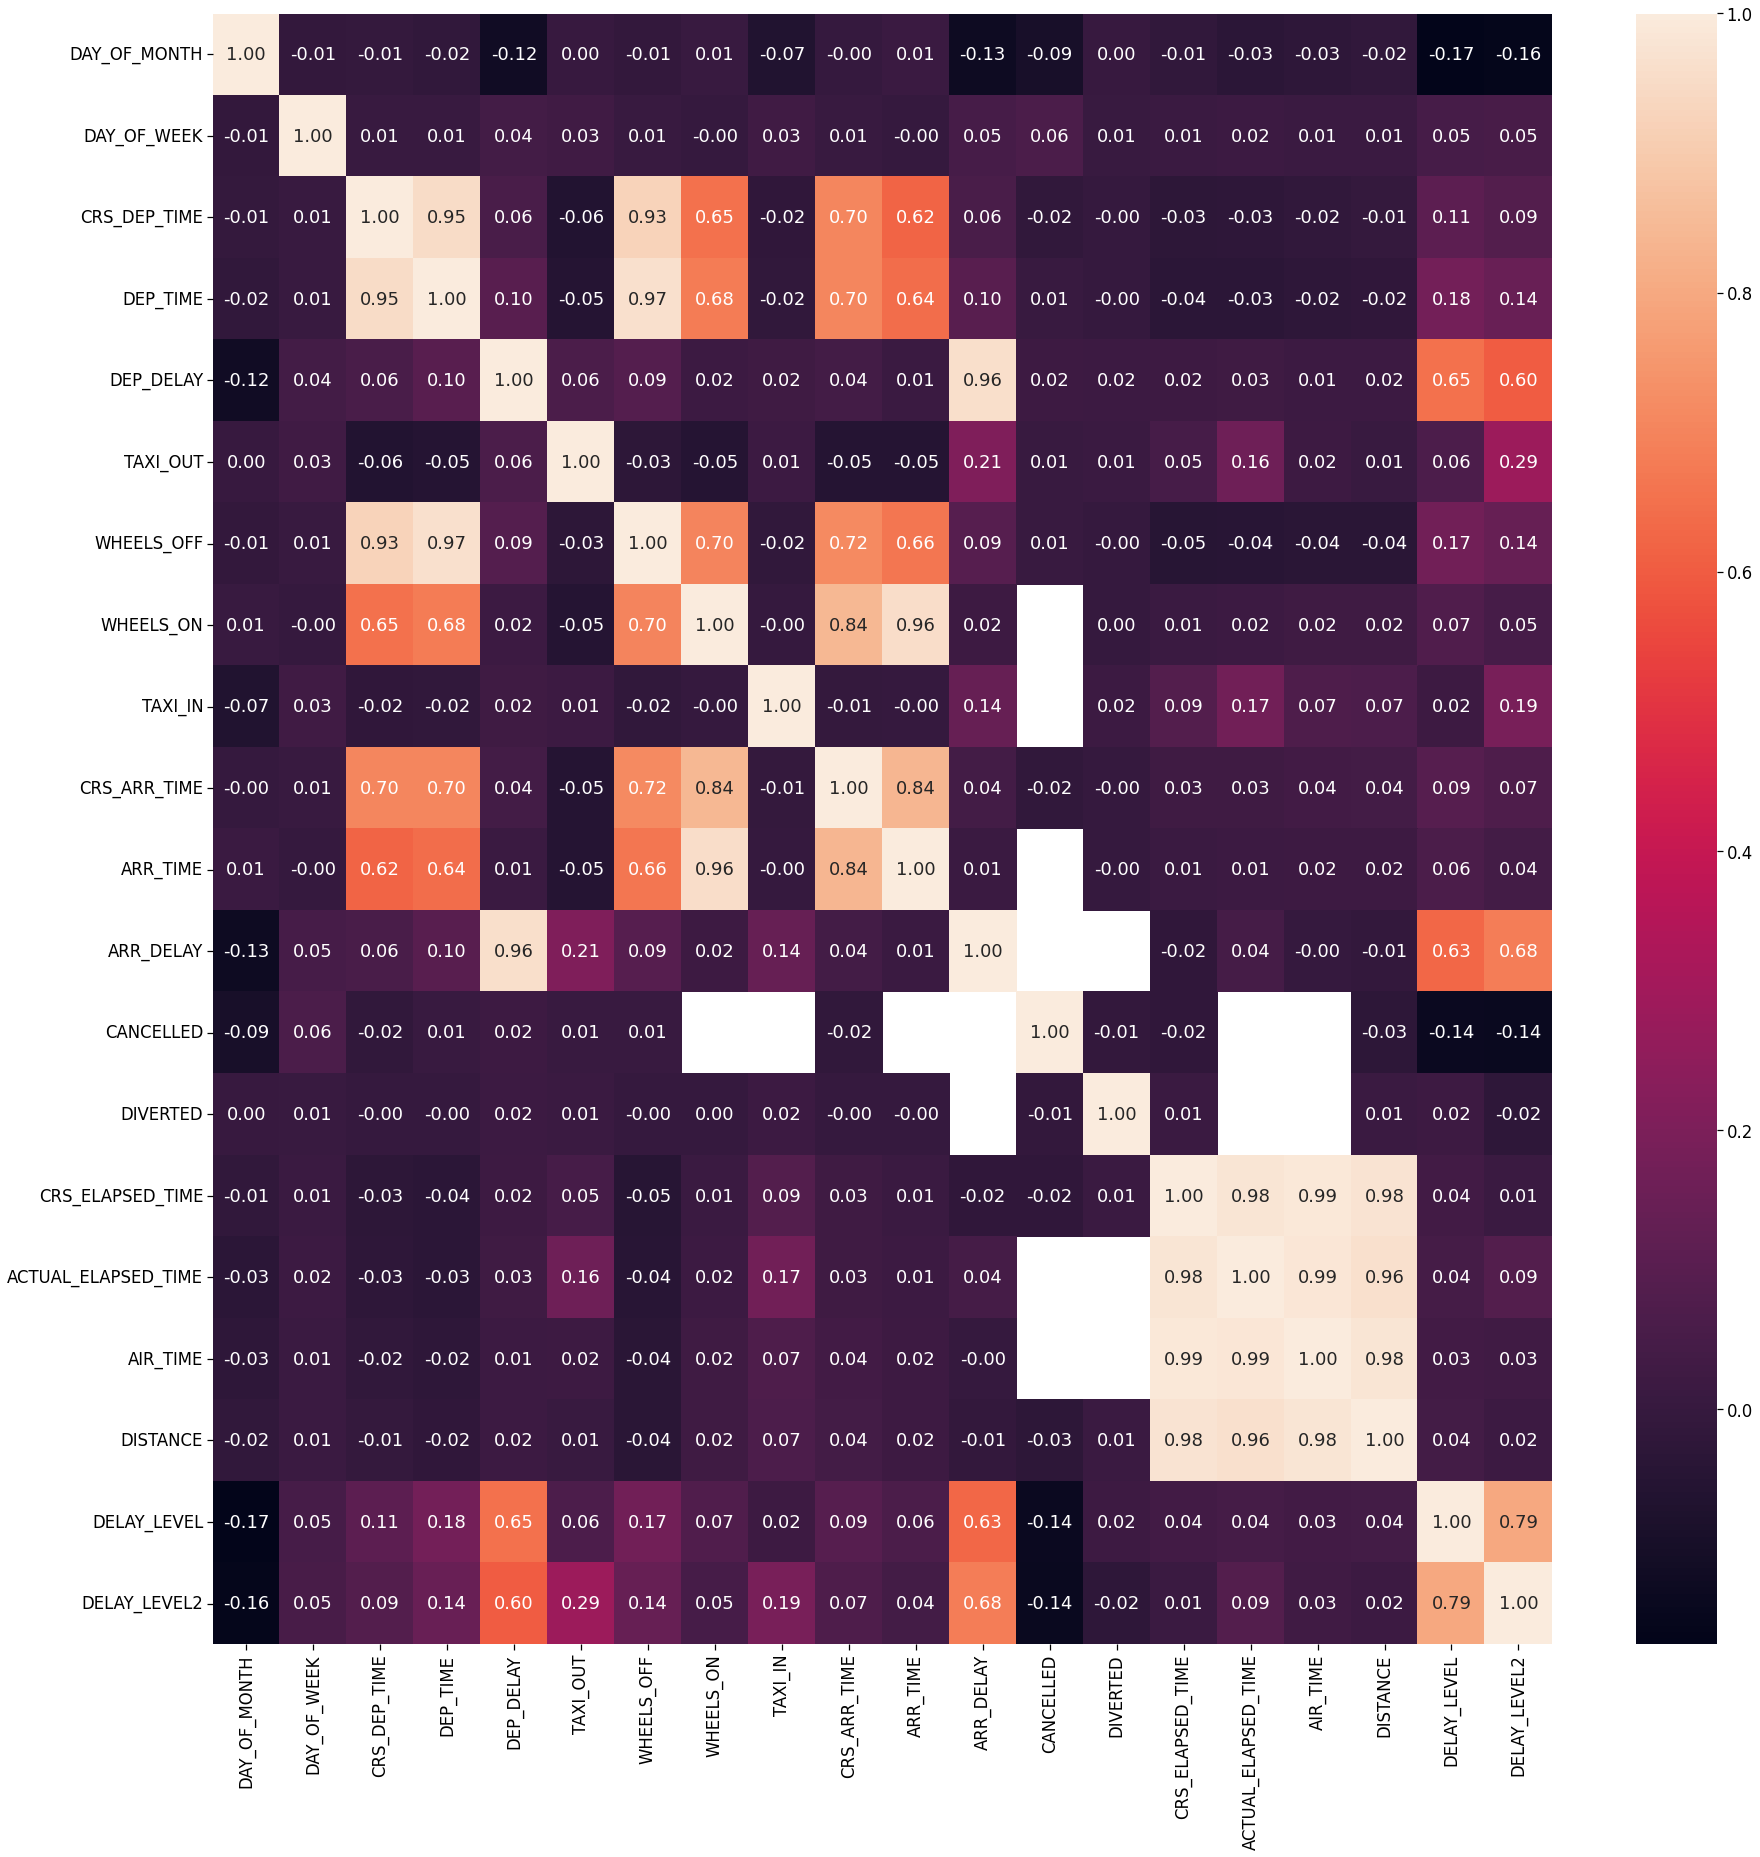

In [51]:
axis = plt.subplots(figsize=(30, 30))
sns.heatmap(data[c].corr(), annot=True, fmt=".2f")
plt.show()

In [52]:
def findWholeWord(black, word):
    word = word.lower()
    res = False
    for w in black:
        if(re.search(w, word)):
            res = True
    return res

def select_cols(corre, th, black_list, col):
    tmp = pd.DataFrame(corre[col]).reset_index()
    c = []
    for index, row in tmp.iterrows():
        if(not(findWholeWord(black_list, row['index']))):            
            if(row[col]>=th):
                c.append(row['index'])
            elif(row[col]<=-th):
                c.append(row['index'])
    try:
        c.remove(col)
    except:
        pass
    
    return c

In [53]:
th = .6
black_list = []
cc = select_cols(data[c].corr(), th, black_list, 'ARR_DELAY')
cc

['DEP_DELAY', 'DELAY_LEVEL', 'DELAY_LEVEL2']

# Prediction

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



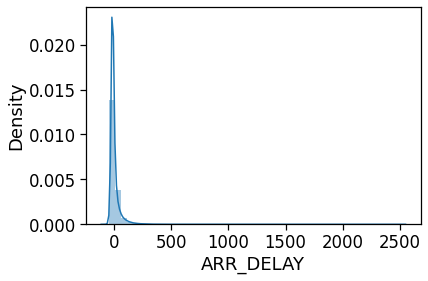

In [54]:
sns.distplot(data['ARR_DELAY'])
plt.show()

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



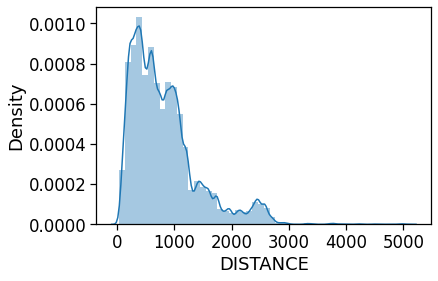

In [55]:
sns.distplot(data['DISTANCE'])
plt.show()

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



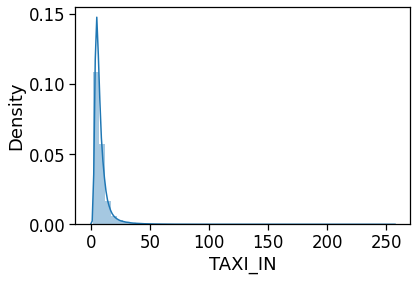

In [56]:
sns.distplot(data['TAXI_IN'])
plt.show()

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



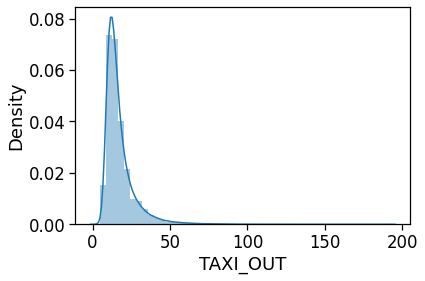

In [57]:
sns.distplot(data['TAXI_OUT'])
plt.show()

In [58]:
Las = Lasso()
LinR = LinearRegression()
Rid = Ridge()
Rfc = RandomForestRegressor(random_state=2)

In [59]:
le = LabelEncoder()

In [60]:
data.columns

Index(['YEAR', 'QUARTER', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE',
       'OP_UNIQUE_CARRIER', 'OP_CARRIER', 'ORIGIN_AIRPORT_ID',
       'ORIGIN_CITY_NAME', 'ORIGIN_STATE_NM', 'DEST_AIRPORT_ID',
       'DEST_CITY_NAME', 'DEST_STATE_NM', 'CRS_DEP_TIME', 'DEP_TIME',
       'DEP_DELAY', 'DEP_DELAY_NEW', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON',
       'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'ARR_DELAY_NEW',
       'CANCELLED', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME',
       'AIR_TIME', 'DISTANCE', 'Actual_Departure', 'Actual_WHEELS_OFF',
       'Actual_WHEELS_ON', 'Actual_Arrival', 'airline', 'DELAY_LEVEL',
       'DELAY_LEVEL2'],
      dtype='object')

In [61]:
cols =['DAY_OF_MONTH', 'DAY_OF_WEEK',
       'DEP_DELAY',
       'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN',
       'ARR_TIME', 'CANCELLED', 'DIVERTED',
       'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       ]

In [62]:
data.dropna(subset=['ARR_DELAY'], inplace=True)

In [63]:
for col in cols:
    data[col].fillna(0, inplace=True)

In [64]:
X = data[cols]
X.shape

(503529, 13)

In [65]:
y = data['ARR_DELAY']

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 2)

In [67]:
sc1 = StandardScaler()
X_train_sc = sc1.fit_transform(X_train)
X_test_sc = sc1.transform(X_test)

In [68]:
X_test_sc

array([[-0.24688238,  0.4769701 , -0.3404158 , ..., -0.70310715,
        -0.66012323, -0.64061082],
       [-1.48478081, -1.44923953,  0.14430379, ..., -1.35094902,
        -1.19729072, -1.07274226],
       [-1.03463592,  0.4769701 , -0.23943255, ...,  1.94339582,
         2.11053016,  2.62139304],
       ...,
       [-0.9220997 ,  0.95852251, -0.23943255, ..., -0.42742975,
        -0.32085955, -0.32449911],
       [-1.25970837, -0.48613472,  0.24528704, ...,  1.44717652,
         0.5838436 ,  0.94162919],
       [-1.48478081, -1.44923953, -0.27982585, ..., -0.19310397,
        -0.15122771,  0.00506417]])

In [69]:
result = pd.DataFrame()

# Model fitting and results

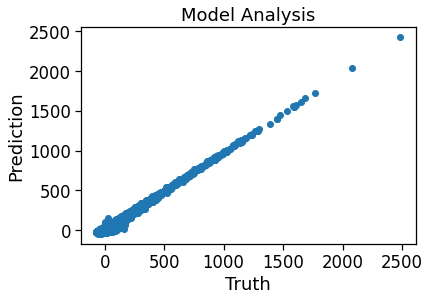

Lasso  is done;


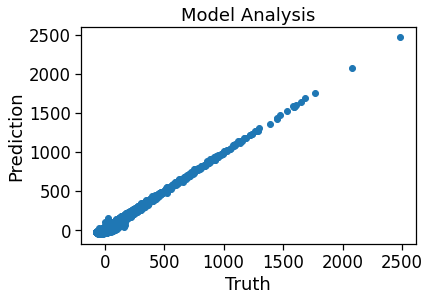

Linear Regression  is done;


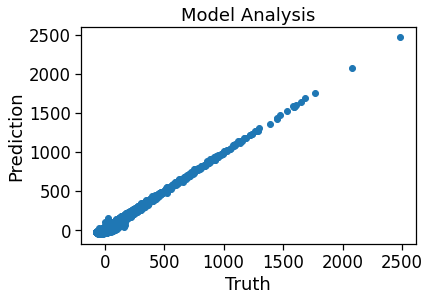

Ridge  is done;


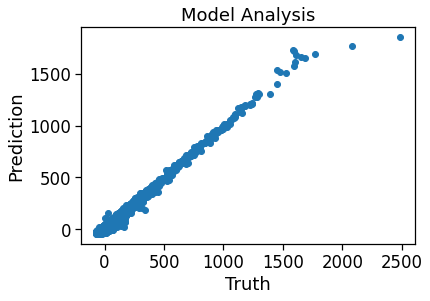

Random forest Regressor  is done;


In [70]:
for model, name in zip([Las, LinR, Rid, Rfc], 
     ['Lasso', 'Linear Regression', 'Ridge', 'Random forest Regressor']):
    
    start_time = time.time()
    model1 = model.fit(X_train_sc, y_train)
    result.at[name, 'train time'] = time.time() - start_time
    
    start_time = time.time()
    Y_predict = model1.predict(X_test_sc)
    result.at[name, 'test time'] = time.time() - start_time

    result.at[name, 'name'] = name
    result.at[name, 'MAE'] = mean_absolute_error(y_test, Y_predict)
    result.at[name, 'MSE'] = mean_squared_error(y_test, Y_predict)
    result.at[name, 'RMSE'] = np.sqrt(mean_squared_error(y_test, Y_predict))
    result.at[name, 'R2'] = r2_score(y_test, Y_predict)
    
    plt.scatter(y_test, Y_predict)
    plt.title("Model Analysis")
    plt.xlabel("Truth")
    plt.ylabel("Prediction")
    plt.show()
    
    print(name, ' is done;')

In [71]:
result

,train time,test time,name,MAE,MSE,RMSE,R2
Lasso,0.082124,0.004176,Lasso,7.933283,110.642329,10.518666,0.961277
Linear Regression,0.135026,0.003573,Linear Regression,7.740526,102.878039,10.142881,0.963995
Ridge,0.043290,0.004513,Ridge,7.740520,102.878019,10.142880,0.963995
Random forest Regressor,429.703674,10.785962,Random forest Regressor,7.064023,90.903297,9.534322,0.968186


# Classifer

In [72]:
def func(x):
    if x < 0:
        return -1
    elif x > 0:
        return 1
    else:
        return 0

In [73]:
data['Target'] = data['ARR_DELAY'].apply(func)

In [74]:
data['Target'].value_counts()

-1    328469
 1    167007
 0      8053
Name: Target, dtype: int64

In [75]:
y = data['Target']

In [76]:
X.shape

(503529, 13)

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 2)

In [78]:
sc1 = StandardScaler()
X_train_sc = sc1.fit_transform(X_train)
X_test_sc = sc1.transform(X_test)

In [79]:
result2 = pd.DataFrame()

In [81]:
from sklearn.linear_model import LogisticRegression

In [82]:
dt = tree.DecisionTreeClassifier()
rf = RandomForestClassifier()
lr = LogisticRegression()
knn = KNeighborsClassifier()

In [83]:
for model, name in zip([knn, dt, rf, lr], 
     ['KNeighbors', 'Decision Tree','Random forest','Logistic Regression']):
    
    start_time = time.time()
    model1 = model.fit(X_train_sc, y_train)
    result2.at[name, 'train time'] = time.time() - start_time
    
    start_time = time.time()
    Y_predict = model1.predict(X_test_sc)
    result2.at[name, 'test time'] = time.time() - start_time

    result2.at[name, 'name'] = name
    result2.at[name, 'acc'] = metrics.accuracy_score(y_test, Y_predict)
    result2.at[name, 'pre'] = metrics.precision_score(y_test, Y_predict, average='weighted')
    result2.at[name, 'recall'] = metrics.recall_score(y_test, Y_predict, average='weighted')
    result2.at[name, 'f1'] = metrics.f1_score(y_test, Y_predict, average='weighted')
    
    print(name, ' is done;')

KNeighbors  is done;
Decision Tree  is done;
Random forest  is done;
Logistic Regression  is done;


/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [84]:
result2

,train time,test time,name,acc,pre,recall,f1
KNeighbors,3.632582,62.757226,KNeighbors,0.854408,0.843671,0.854408,0.843595
Decision Tree,5.190285,0.052200,Decision Tree,0.829517,0.832488,0.829517,0.830993
Random forest,97.426357,5.291223,Random forest,0.887600,0.873077,0.887600,0.878857
Logistic Regression,15.448409,0.012864,Logistic Regression,0.878015,0.863537,0.878015,0.869025


In [86]:
data['Target'] = data['DEP_DELAY'].apply(func)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 2)

sc1 = StandardScaler()
X_train_sc = sc1.fit_transform(X_train)
X_test_sc = sc1.transform(X_test)

result3 = pd.DataFrame()

dt = tree.DecisionTreeClassifier()
rf = RandomForestClassifier()
lr = LogisticRegression()
knn = KNeighborsClassifier()

for model, name in zip([knn, dt, rf, lr], 
     ['KNeighbors', 'Decision Tree','Random forest','Logistic Regression']):
    
    start_time = time.time()
    model1 = model.fit(X_train_sc, y_train)
    result2.at[name, 'train time'] = time.time() - start_time
    
    start_time = time.time()
    Y_predict = model1.predict(X_test_sc)
    result3.at[name, 'test time'] = time.time() - start_time

    result3.at[name, 'name'] = name
    result3.at[name, 'acc'] = metrics.accuracy_score(y_test, Y_predict)
    result3.at[name, 'pre'] = metrics.precision_score(y_test, Y_predict, average='weighted')
    result3.at[name, 'recall'] = metrics.recall_score(y_test, Y_predict, average='weighted')
    result3.at[name, 'f1'] = metrics.f1_score(y_test, Y_predict, average='weighted')
    
    print(name, ' is done;')
    
result3

KNeighbors  is done;
Decision Tree  is done;
Random forest  is done;


/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



Logistic Regression  is done;


,test time,name,acc,pre,recall,f1
KNeighbors,59.595292,KNeighbors,0.825889,0.809538,0.825889,0.80496
Decision Tree,0.010606,Decision Tree,1.000000,1.000000,1.000000,1.00000
Random forest,1.520381,Random forest,1.000000,1.000000,1.000000,1.00000
Logistic Regression,0.012525,Logistic Regression,1.000000,1.000000,1.000000,1.00000


# conclusion

+ The maximum arrival delay is determined by the departure delay of the airport

+ Creating delays in the aviation industry is primarily caused by departure delays

+ There are various reasons for departure delays, including security delays, airline system delays, and airline delays.